# Effekte von Policies


Heute schauen wir uns gemeinsam an, welchen Effekt eine politische Maßnahme (eine Policy) auf eine Bevölkerung haben kann. Fukus sind Einkommen und CO2 Fußabdruck.

Jeder Haushalt hat:

- ein bestimmtes Einkommen
- einen bestimmten CO₂-Ausstoß pro Jahr

Und jetzt führen wir eine Policy ein, zum Beispiel eine CO₂-Steuer mit Rückverteilung. Die große Frage ist:

Wie verändert sich dadurch die Einkommensverteilung und die gesamten CO₂-Emissionen?

Wir wollen das nicht nur theoretisch diskutieren, sondern im Code nachbauen und simulieren:
Was passiert mit den ärmeren Haushalten? Was mit den reicheren? Und wie verändert sich am Ende die Summe aller Emissionen?



## Einkommen und CO₂-Emissionen – wie hängt das zusammen?

Ganz grob  kann man sagen: Wer mehr Einkommen hat, kann sich mehr leisten und verursacht somit (im Mittel) auch mehr CO2.
Wichtig:
Das ist ein durchschnittlicher Zusammenhang, kein Naturgesetz.
Es gibt auch reiche Haushalte mit geringem Fußabdruck (z.B. sehr konsequenter Klimaschutz im Alltag), und ärmere Haushalte mit relativ hohen Emissionen (z.B. lange Pendelwege mit altem Auto).

In jedem Fall ist dieser Zusammenhang nicht linear, deswegen macht es Sinn ein Modell zu machen um das System besser zu verstehen.

## Einkommen generieren
Die Funktion randomincome erzeugt für uns ein zufälliges Haushaltseinkommen, das realistisch ungleich verteilt ist (einige wenige hohe Einkommen, viele mittlere und niedrigere).



In [7]:
import numpy as np
import matplotlib.pyplot as plt

def randomincome(mean=4800, gini = 0.45):
    inc = np.random.lognormal(np.log(mean), gini)
    return inc

`np.random.lognormal(np.log(mean), gini)` zieht eine Zufallszahl aus einer Lognormalverteilung – das ist eine Verteilung, die gut dazu passt, wie Einkommen in der Realität aussehen: schief verteilt, mit wenigen hohen Einkommen und vielen niedrigeren.



Über die Parameter mean (durchschnittliches Einkommen) und gini (Ungleichheitsgrad) können wir später steuern, wie reich und wie ungleich unsere simulierte Gesellschaft ist.

## Zusammenhang zu CO2
Die Funktion `co2` nimmt ein Einkommen und berechnet daraus einen geschätzten CO₂-Ausstoß für diesen Haushalt – nach dem Motto: höheres Einkommen ⇒ tendenziell höherer CO₂-Fußabdruck.


In [2]:
def co2(income):
    base_co2 = 1.5
    slope_co2 = 1.2
    
    log_income = np.log(income)
    co2 = base_co2 + slope_co2 * log_income
    

    return co2

`log_income = np.log(income)` nimmt den Logarithmus vom Einkommen. Damit glätten wir den Zusammenhang: wenn das Einkommen sehr stark steigt, wachsen die CO₂-Emissionen nicht mehr ganz so extrem, sondern etwas abgeflacht.



`co2_value = base_co2 + slope_co2 * log_income` sagt: wir starten bei einem Basiswert base_co2 und addieren einen Betrag, der vom (geloggten) Einkommen abhängt. So bekommen Haushalte mit höherem Einkommen im Modell automatisch höhere CO₂-Werte, ohne dass wir überall extra Regeln hinschreiben müssen.

## Eine neue Klasse
Jetzt bauen wir uns eine Klasse Household, mit der wir einzelne Haushalte als Objekte darstellen können – jeweils mit einem Einkommen und einem dazugehörigen CO₂-Wert.

Die Klasse sieht so aus:




In [3]:
class Household:
    def __init__(self, income):
        self.income = income
        self.co2 = co2(income)

Achtung: Die Initialisuerungsmethode (auch Konstruktor genannt) hat diesmal ein Argument, nämlich das Einkommen. Aus diesem Einkommen berechnen wir dann auch gleich das CO2 mit der Funktion, die wir schon haben.

Jetzt testen wir die Klasse Household, indem wir:

- eine main()-Funktion schreiben,
- darin eine Liste von Haushalten erzeugen,
- diese Liste mit einer plot Funktion visualisieren.

In der Plot Funktion machen wir Listen aus den Einkommen und Emissionen und sortieren sie der Größe nach (damit der Plot übersichtlich bleibt).
Unser Hauptprogramm packen wir ein eine eigene Funktion.


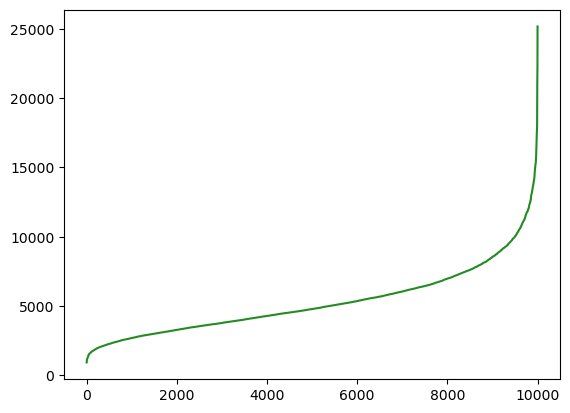

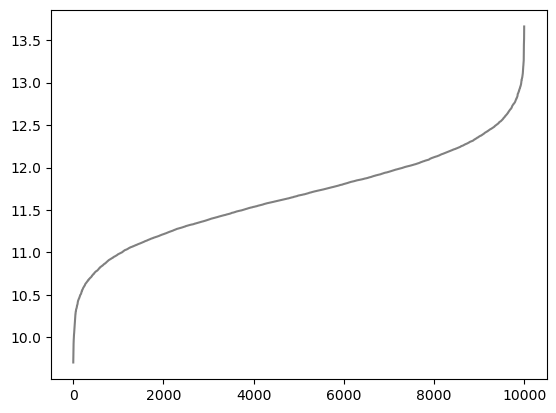

In [8]:
def plothouseholds(hh):
    incs=[]
    co2s=[]
    for h in hh:
        incs.append(h.income)
        co2s.append(h.co2)
    incs=sorted(incs)
    co2s = sorted(co2s)
    plt.figure()
    plt.plot(incs, color="forestgreen")
    plt.figure()
    plt.plot(co2s,color="gray")
    plt.show()

def main():
    households = []
    for it in range(10000):
        households.append(Household(randomincome()))
    plothouseholds(households)


main()

## Eine CO2 Steuer

Jetzt möchten wir den Effekt einer CO2 Steuer modellieren. Für jede Tonne CO2 muss man Steuern zahlen. Die Einnahmen dieser Steuern werden dann gleichmäßig auf die Bevölkerung aufgeteilt. So kann eine Function aussehen, die genau das macht: Sie nimmt als Input eine Liste mit households und gibt auch wieder eine solche Liste zurück.

In [9]:
def co2_tax(hh, co2cost=500):
   
    taxes = []
    for h in hh:
        tax = co2cost * h.co2
        taxes.append(tax)

   
    transfer =  sum(taxes)/ len(hh)
   

    for it in range(len(hh)):
        hh[it].income = hh[it].income - taxes[it] + transfer

    return hh

Testen wir was diese Steuer macht. Dazu schreiben wir zuerst eien Function, die zwei `households` vergleicht. Außerdem brauchen wir noch eien Function, die die CO2 Emissionen aller Haushalte neu berechnet (wenn sich z.B. das Einkommen druch Steuern geändert hat).

In [10]:
def compareplot(a,b):
    incsa=[]
    incsb=[]
    co2sa=[]
    co2sb=[]

    for h in a:
        incsa.append(h.income)
        co2sa.append(h.co2)
    for h in b:
        incsb.append(h.income)
        co2sb.append(h.co2)

    incsa=sorted(incsa)
    incsb=sorted(incsb)
    co2sa=sorted(co2sa)
    co2sb=sorted(co2sb)

    plt.figure()

    plt.plot(incsa,color="lime")
    plt.plot(incsb,color="forestgreen")

    plt.figure()
    
    plt.plot(co2sa,color="gray")
    plt.plot(co2sb,color="black")
    

    print("poorest household:",incsa[0],"->",incsb[0])
    print("overall emissions:",sum(co2sa),"->",sum(co2sb))

    plt.show()

def updateco2(hh):
    for h in hh:
        h.co2 = co2(h.income)

Jetzt können wir unsere Policy testen. Dafür müssen wir nur 2 Listen mit households erzeugen. Eine normale und eine, die dadurch entstanden ist, dass wir die CO2-Steuer Function verwendet haben.

Aber Achtung: Wenn wir die "alte" Liste ganz normal unter einem neuen Namen abspeichern, bekommen wir ein Problem: Auch wenn man der Liste einen neuen Namen gibt: In Python bleiben die Inhalte standardmäßig die gleichen. Wenn ich also Liste A und Liste B habe, und beide beinhalten die gleichen Households, dann ändert sich auch Liste B, wenn ich etwas an einem household von Liste A ändere. Wenn man dieses Verhalten nicht will (wie in unserem Fall) müssen wir nicht nur eine neue Liste erstellen, sondern auch jedes Element in der Liste einzeln kopieren. Das geht elegant mit einer so genannten deep copy.



poorest household: 1021.9711691901274 -> 1950.128479367102
overall emissions: 116717.0089256988 -> 117010.32977123909


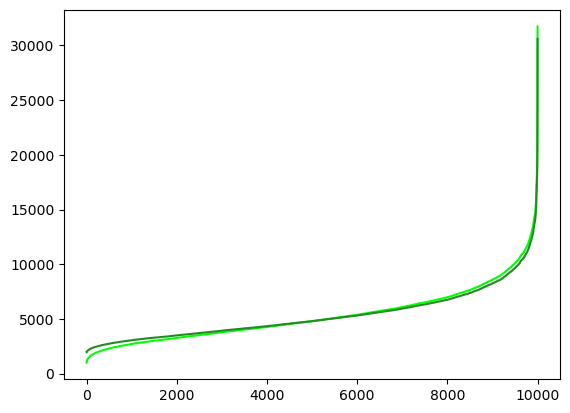

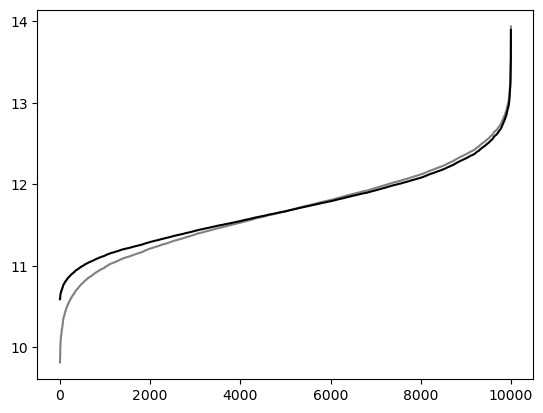

In [12]:
import copy
def main():
    households = []
    for it in range(10000):
        households.append(Household(randomincome()))
    households_old=copy.deepcopy(households)

    households2=co2_tax(households)

    updateco2(households2)
    compareplot(households_old,households2)

main()

Nun können wir versuchen zu interpretieren, was wir sehen. 

Der ärmste Haushalt hat nach der Steuer deutlich mehr Geld (fast doppelt so viel). Macht Sinn: Er hat am wenigsten Steuern gezahlt und gleich viel Transferleistung bekommen wie alle anderen. Was uns mehr überascht: die Emissionen sind nicht gesunken. Im Gegenteil, sie sind sogar leicht gestiegen. Woran kann das liegen?

Achtung bei der Interpretation: Dieses Modell beinhaltet noch keine explizite Verhaltensänderung: Die neuen CO2 Werte kommen nur daher, dass die Menschen mehr bzw. weniger Geld zur Verfügung haben als vorher. Sie "wissen" noch nicht, dass CO2 jetzt etwas kostet und passen ihr Verhalten noch nicht daran an. Wie stark der Effekt wäre, ist leider nicht gut genug verstanden um ihn sinnvoll ins Modell einzubauen.

## Zusammenfassung
**Konstruktoren**  
Ein Konstruktor ist eine spezielle Methode, die beim Erzeugen eines Objekts automatisch aufgerufen wird und dessen Anfangszustand festlegt. Man verwendet ihn, um Anfangswerte zu setzen und sicherzustellen, dass ein Objekt direkt nach der Erstellung „benutzbar“ ist. Konstruktoren sind wichtig, um komplexe Datenstrukturen kontrolliert und konsistent aufzubauen.

**sorted**  
sorted ist eine Funktion, die aus einer beliebigen iterierbaren Datenstruktur (z.B. Liste, Tupel) eine neue, sortierte Liste erzeugt, ohne das Original zu verändern. Man verwendet sie, um Elemente nach einem bestimmten Kriterium zu ordnen, etwa numerisch oder alphabetisch. Sie ist nützlich, um Daten strukturiert darzustellen, effizient zu durchsuchen oder für weitere Berechnungen vorzubereiten.

**deepcopy**  
deepcopy erstellt eine vollständige, unabhängige Kopie eines komplexen Objekts, inklusive aller darin enthaltenen verschachtelten Objekte. Man verwendet es, wenn Änderungen an der Kopie auf keinen Fall das Original beeinflussen sollen. Es ist wichtig, um Seiteneffekte zu vermeiden, insbesondere bei großen Datenstrukturen, die an verschiedene Teile eines Programms weitergegeben werden.